In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd

In [20]:
data_folder = "/home/sputnik/main/MyFolder/DL_Practice/prob1_data" 
output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"

In [21]:
X_df = pd.read_excel(output_file, header=None)

X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Shape of X:", X.shape)


Shape of X: (5000, 226)


In [22]:
num_samples = X.shape[0]

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    von_mises_stress = stress_data[:, 0]
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Shape of y:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))
print("Mean max stress:", np.mean(y))


Shape of y: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609
Mean max stress: 9497545.137606278


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4000, 226)
X_test: (1000, 226)
y_train: (4000, 1)
y_test: (1000, 1)


In [24]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [ ]:

grid_rows, grid_cols = 11, 21
target_size = grid_rows * grid_cols  

pad_size = target_size - X_train_scaled.shape[1]

X_train_cnn = np.pad(X_train_scaled, ((0,0),(0,pad_size)), mode='constant', constant_values=0)
X_test_cnn  = np.pad(X_test_scaled,  ((0,0),(0,pad_size)), mode='constant', constant_values=0)

X_train_cnn = X_train_cnn.reshape(-1, grid_rows, grid_cols, 1)
X_test_cnn  = X_test_cnn.reshape(-1, grid_rows, grid_cols, 1)

print("X_train_cnn shape:", X_train_cnn.shape)  # (4000, 11, 21, 1)
print("X_test_cnn shape:",  X_test_cnn.shape)   # (1000, 11, 21, 1)

X_train_cnn shape: (4000, 11, 21, 1)
X_test_cnn shape: (1000, 11, 21, 1)


In [26]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [27]:
print("Loading stress fields...")

Y_field = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    stress_data = np.loadtxt(stress_file)
    
    von_mises = stress_data[:, 0]  # all 3304 stress values
    Y_field.append(von_mises)
    
    if i % 500 == 0:
        print(f"  Processed {i}/{num_samples}")

Y_field = np.array(Y_field)  # (5000, 3304)
print("\nY_field shape:", Y_field.shape)

# Sanity check — max of field should match y exactly
print("\nSanity check:")
print(f"  Max stress in Y_field[0] : {Y_field[0].max():.2f}")
print(f"  Actual max stress y[0]   : {y[0][0]:.2f}")

Loading stress fields...
  Processed 0/5000
  Processed 500/5000
  Processed 1000/5000
  Processed 1500/5000
  Processed 2000/5000
  Processed 2500/5000
  Processed 3000/5000
  Processed 3500/5000
  Processed 4000/5000
  Processed 4500/5000

Y_field shape: (5000, 3304)

Sanity check:
  Max stress in Y_field[0] : 9380992.86
  Actual max stress y[0]   : 9380992.86


In [28]:

_, _, Y_field_train, Y_field_test = train_test_split(X, Y_field, test_size=0.2, random_state=42)

print("Y_field_train shape:", Y_field_train.shape)  # (4000, 3304)
print("Y_field_test shape:", Y_field_test.shape)    # (1000, 3304)

Y_field_mean = np.mean(Y_field_train, axis=0)  # (3304,) — per node mean
Y_field_std  = np.std(Y_field_train, axis=0)   # (3304,) — per node std
Y_field_std[Y_field_std == 0] = 1              

Y_field_train_scaled = (Y_field_train - Y_field_mean) / Y_field_std
Y_field_test_scaled  = (Y_field_test  - Y_field_mean) / Y_field_std

print("Y_field_train_scaled shape:", Y_field_train_scaled.shape)
print("Y_field_test_scaled shape:", Y_field_test_scaled.shape)
print(f"Mean of scaled Y_field_train:{Y_field_train_scaled.mean():.4f}")
print(f"Std  of scaled Y_field_train:{Y_field_train_scaled.std():.4f}")

Y_field_train shape: (4000, 3304)
Y_field_test shape: (1000, 3304)
Y_field_train_scaled shape: (4000, 3304)
Y_field_test_scaled shape: (1000, 3304)
Mean of scaled Y_field_train:0.0000
Std  of scaled Y_field_train:1.0000


In [ ]:
def build_unet(input_dim=226, output_dim=3304):
    inputs = Input(shape=(input_dim,))
    
    e1 = Dense(256, activation='relu')(inputs) 
    e2 = Dense(512, activation='relu')(e1)      
    e3 = Dense(256, activation='relu')(e2)      
    e4 = Dense(128, activation='relu')(e3)      

    b = Dense(64, activation='relu')(e4)         
    d1 = Dense(128, activation='relu')(b)   
    d1 = layers.Add()([d1, e4])                  
    
    d2 = Dense(256, activation='relu')(d1)  
    d2 = layers.Add()([d2, e3])                  

    d3 = Dense(512, activation='relu')(d2)  
    d3 = layers.Add()([d3, e2])                  

    d4 = Dense(256, activation='relu')(d3)  
    d4 = layers.Add()([d4, e1])                  
    
    outputs = Dense(output_dim, activation='linear')(d4)
    
    model = Model(inputs, outputs)
    return model

unet_model = build_unet(input_dim=226, output_dim=3304)
unet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 226)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │     58,112 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │    131,584 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    131,328 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     32,896 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │      8,320 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128)       │          0 │ dense_15[0][0],   │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256)       │     33,024 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256)       │          0 │ dense_16[0][0],   │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 512)       │    131,584 │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 512)       │          0 │ dense_17[0][0],   │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │    131,328 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 256)       │          0 │ dense_18[0][0],   │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 3304)      │    849,128 │ add_7[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,515,560 (5.78 MB)

 Trainable params: 1,515,560 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
unet_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=[r2metric])

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss',patience=20, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)]

history_unet = unet_model.fit(
    X_train_scaled, Y_field_train_scaled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.8781 - r2metric: 0.1206 - val_loss: 0.7570 - val_r2metric: 0.2288 - learning_rate: 0.0010
Epoch 2/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6574 - r2metric: 0.3413 - val_loss: 0.6088 - val_r2metric: 0.3797 - learning_rate: 0.0010
Epoch 3/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.5332 - r2metric: 0.4659 - val_loss: 0.5420 - val_r2metric: 0.4477 - learning_rate: 0.0010
Epoch 4/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4742 - r2metric: 0.5250 - val_loss: 0.5082 - val_r2metric: 0.4822 - learning_rate: 0.0010
Epoch 5/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4409 - r2metric: 0.5584 - val_loss: 0.4877 - val_r2metric: 0.5031 - learning_rate: 0.0010
Epoch 6/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.4194 - r2metric: 0.5803 - val_loss: 0.4743 - val_r2metric: 0.5167 - learning_rate: 0.0010
Epoch 7/200
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4048 - r2met

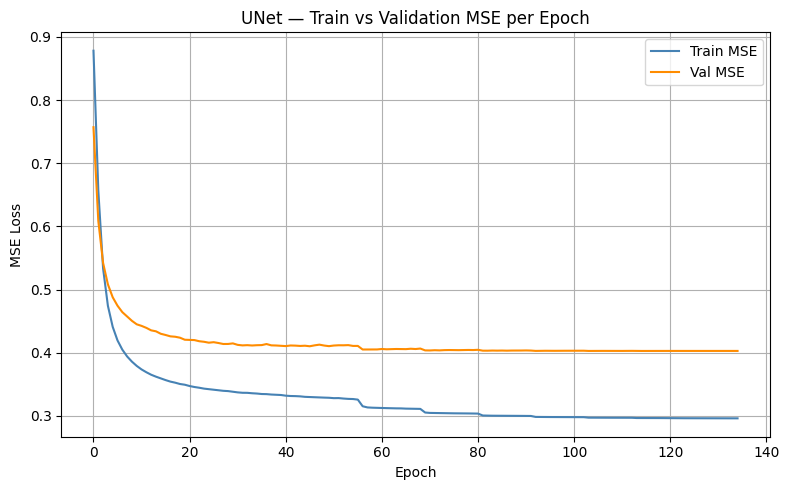

In [32]:

plt.figure(figsize=(8, 5))
plt.plot(history_unet.history['loss'],     label='Train MSE', color='steelblue')
plt.plot(history_unet.history['val_loss'], label='Val MSE',   color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('UNet — Train vs Validation MSE per Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('UnetMSEvsEpochs.png', dpi=150)
plt.show()

In [33]:

Y_pred_train_scaled = unet_model.predict(X_train_scaled)
Y_pred_test_scaled  = unet_model.predict(X_test_scaled)

Y_pred_train = Y_pred_train_scaled * Y_field_std + Y_field_mean
Y_pred_test  = Y_pred_test_scaled  * Y_field_std + Y_field_mean

y_pred_max_train = Y_pred_train.max(axis=1).reshape(-1, 1)  # (4000, 1)
y_pred_max_test  = Y_pred_test.max(axis=1).reshape(-1, 1)   # (1000, 1)

from sklearn.metrics import r2_score
r2_field_train = r2_score(Y_field_train, Y_pred_train)
r2_field_test  = r2_score(Y_field_test,  Y_pred_test)

r2_max_train = r2_score(y_train, y_pred_max_train)
r2_max_test  = r2_score(y_test,  y_pred_max_test)

mape_max_train = np.mean(np.abs((y_train - y_pred_max_train) / y_train)) * 100
mape_max_test  = np.mean(np.abs((y_test  - y_pred_max_test)  / y_test))  * 100

print("Full Stress Field")
print(f"Train R² :{r2_field_train:.4f}")
print(f"Test R² :{r2_field_test:.4f}")
print("Max Von Mises Stress")
print(f"Train R²:{r2_max_train:.4f}")
print(f"Test R²:{r2_max_test:.4f}")
print(f"Train MAPE:{mape_max_train:.2f}%")
print(f"Test  MAPE:{mape_max_test:.2f}%")


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Full Stress Field
Train R² :0.6826
Test R² :0.5919
Max Von Mises Stress
Train R²:0.7149
Test R²:0.6633
Train MAPE:11.20%
Test  MAPE:12.75%


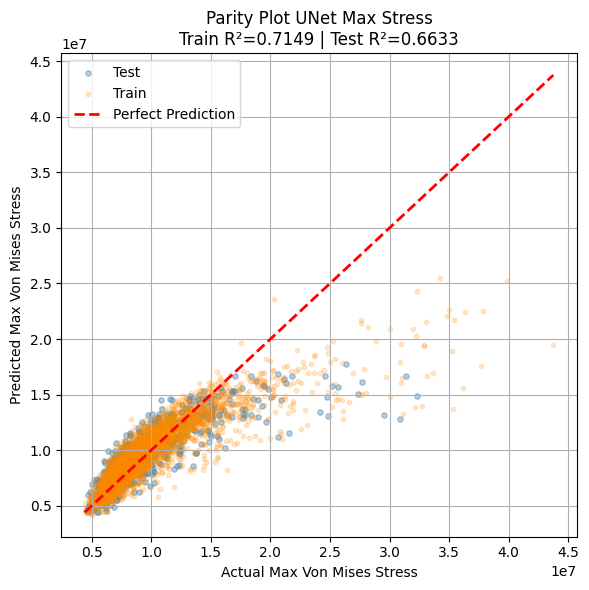

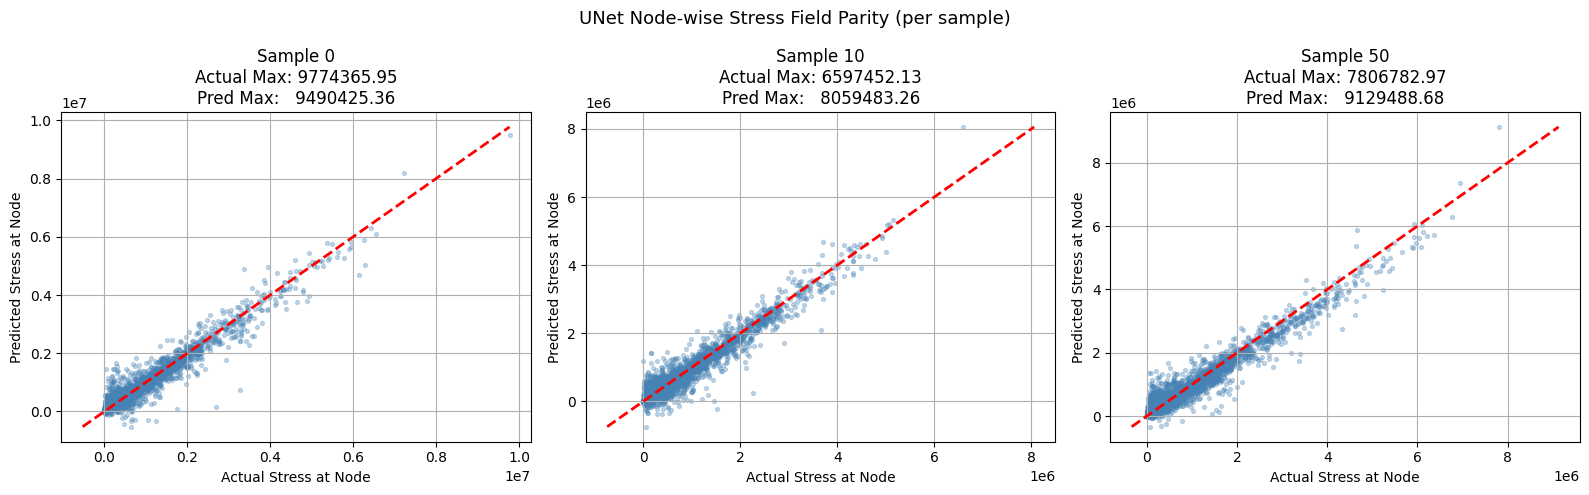

In [34]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test,  y_pred_max_test,  alpha=0.4, s=15, color='steelblue',  label='Test')
plt.scatter(y_train, y_pred_max_train, alpha=0.2, s=10, color='darkorange', label='Train')

mn = min(y_train.min(), y_test.min())
mx = max(y_train.max(), y_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Max Von Mises Stress')
plt.ylabel('Predicted Max Von Mises Stress')
plt.title(f'Parity Plot UNet Max Stress\n'
          f'Train R²={r2_max_train:.4f} | Test R²={r2_max_test:.4f}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('UnetParityMaxstress.png', dpi=150)
plt.show()

sample_indices = [0, 10, 50]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('UNet Node-wise Stress Field Parity (per sample)', fontsize=13)

for idx, sample_idx in enumerate(sample_indices):
    actual    = Y_field_test[sample_idx]
    predicted = Y_pred_test[sample_idx]
    
    mn_ = min(actual.min(), predicted.min())
    mx_ = max(actual.max(), predicted.max())
    
    axes[idx].scatter(actual, predicted, alpha=0.3, s=8, color='steelblue')
    axes[idx].plot([mn_, mx_], [mn_, mx_], 'r--', linewidth=2)
    axes[idx].set_xlabel('Actual Stress at Node')
    axes[idx].set_ylabel('Predicted Stress at Node')
    axes[idx].set_title(f'Sample {sample_idx}\n'
                        f'Actual Max: {actual.max():.2f}\n'
                        f'Pred Max:   {predicted.max():.2f}')
    axes[idx].grid(True)

plt.tight_layout()
plt.savefig('UnetParityNodewise.png', dpi=150)
plt.show()